<a href="https://colab.research.google.com/github/Ananya-Gupta08/Traffic-congestion-prediction/blob/main/Uber_traffic_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
df = pd.read_csv("https://drive.google.com/uc?id=1AOJnbf3qLLabSVrOMGUcS25Z1UryyxSJ")

In [ ]:
df.columns

Index(['DateTime', 'Junction', 'Vehicles', 'ID'], dtype='object')

In [ ]:
df.rename(columns={
    'DateTime': 'timestamp',
    'Junction': 'location',
    'Vehicles': 'traffic',
    'ID': 'id'
}, inplace=True)


In [ ]:
df['timestamp'] = pd.to_datetime(df['timestamp'])

/tmp/ipykernel_1906/966722803.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['timestamp'] = pd.to_datetime(df['timestamp'])


In [ ]:
df.head()

,timestamp,location,traffic,id
0,2015-01-11 00:00:00,1,15,20151101001
1,2015-01-11 01:00:00,1,13,20151101011
2,2015-01-11 02:00:00,1,10,20151101021
3,2015-01-11 03:00:00,1,7,20151101031
4,2015-01-11 04:00:00,1,9,20151101041


In [ ]:
df = df.sort_values(by='timestamp')

In [ ]:
df.isnull().sum()

,0
timestamp,0
location,0
traffic,0
id,0


In [ ]:
df.to_csv("clean_traffic.csv", index=False)

In [ ]:
import numpy as np

weather_df = pd.DataFrame()
weather_df['timestamp'] = df['timestamp']

weather_df['temperature'] = np.random.uniform(20, 35, len(df))
weather_df['humidity'] = np.random.uniform(40, 90, len(df))
weather_df['wind'] = np.random.uniform(0, 15, len(df))
weather_df['rain'] = np.random.choice([0, 0, 0, 1, 2, 5], len(df))
merged = pd.merge(df, weather_df, on='timestamp', how='left')
merged.head()

,timestamp,location,traffic,id,temperature,humidity,wind,rain
0,2015-01-11,1,15,20151101001,25.446981,79.911590,0.216205,1
1,2015-01-11,1,15,20151101001,23.137476,45.237510,10.390932,0
2,2015-01-11,1,15,20151101001,23.832524,61.495035,12.210743,0
3,2015-01-11,2,6,20151101002,25.446981,79.911590,0.216205,1
4,2015-01-11,2,6,20151101002,23.137476,45.237510,10.390932,0


In [ ]:



merged = df.copy()
merged = pd.merge(merged, weather_df, on='timestamp', how='left')

In [ ]:
# Create event df
event_data = [
    {"date": "2015-01-11", "event_type": "None"},
    {"date": "2015-01-12", "event_type": "Public Holiday"},
    {"date": "2015-01-13", "event_type": "Concert"},
    {"date": "2015-01-14", "event_type": "Sports Event"},
    {"date": "2015-01-15", "event_type": "Public Holiday"},
    {"date": "2015-01-16", "event_type": "Concert"},
    {"date": "2015-01-17", "event_type": "Sports Event"},
    {"date": "2015-01-18", "event_type": "None"}
]

event_df = pd.DataFrame(event_data)
event_df['date'] = pd.to_datetime(event_df['date'])

# Extract date
merged['date'] = pd.to_datetime(merged['timestamp'].dt.date)

# Merge
merged = pd.merge(merged, event_df, on='date', how='left')

# Fill missing
merged['event_type'] = merged['event_type'].fillna("None")



In [ ]:
# Create flag
merged['is_event'] = merged['event_type'].map({"None": 0,
    "Public Holiday": 2,
    "Concert": 3,
    "Sports Event": 3})
# Check
merged.head()

,timestamp,location,traffic,id,temperature,humidity,wind,rain,date,event_type,is_event
0,2015-01-11,1,15,20151101001,25.446981,79.911590,0.216205,1,2015-01-11,None,0
1,2015-01-11,1,15,20151101001,23.137476,45.237510,10.390932,0,2015-01-11,None,0
2,2015-01-11,1,15,20151101001,23.832524,61.495035,12.210743,0,2015-01-11,None,0
3,2015-01-11,2,6,20151101002,25.446981,79.911590,0.216205,1,2015-01-11,None,0
4,2015-01-11,2,6,20151101002,23.137476,45.237510,10.390932,0,2015-01-11,None,0


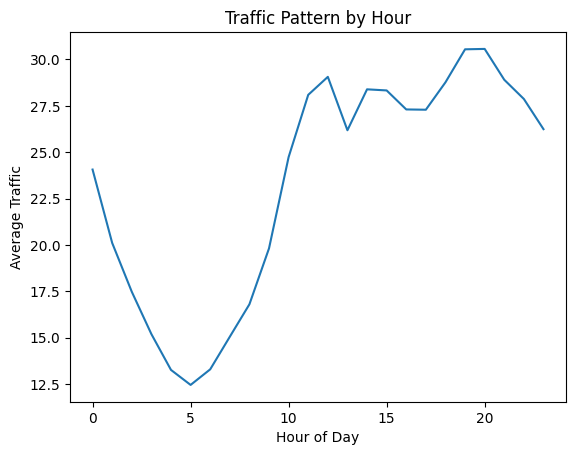

In [ ]:
import matplotlib.pyplot as plt

merged['hour'] = merged['timestamp'].dt.hour

merged.groupby('hour')['traffic'].mean().plot()
plt.xlabel("Hour of Day")
plt.ylabel("Average Traffic")
plt.title("Traffic Pattern by Hour")
plt.show()

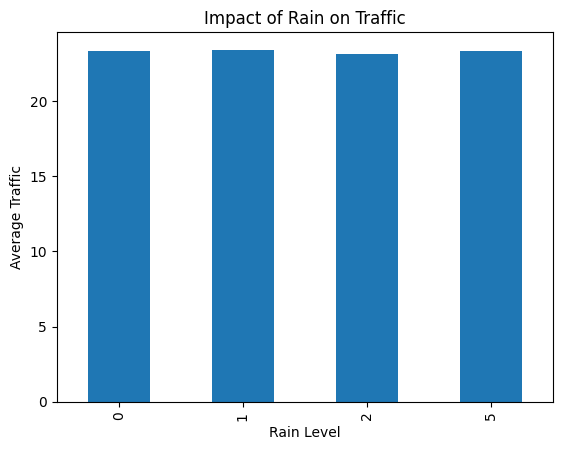

In [ ]:
merged.groupby('rain')['traffic'].mean().plot(kind='bar')
plt.xlabel("Rain Level")
plt.ylabel("Average Traffic")
plt.title("Impact of Rain on Traffic")
plt.show()

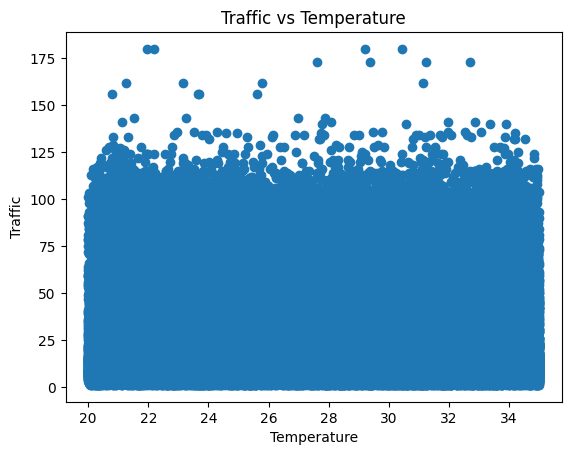

In [ ]:
plt.scatter(merged['temperature'], merged['traffic'])
plt.xlabel("Temperature")
plt.ylabel("Traffic")
plt.title("Traffic vs Temperature")
plt.show()

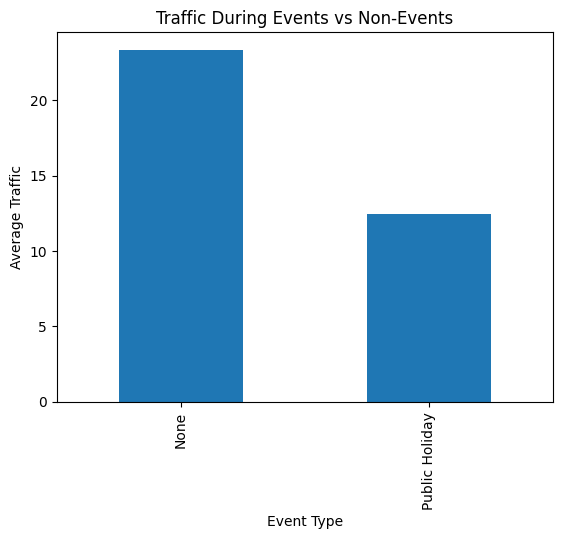

In [ ]:
merged.groupby('event_type')['traffic'].mean().plot(kind='bar')
plt.xlabel("Event Type")
plt.ylabel("Average Traffic")
plt.title("Traffic During Events vs Non-Events")
plt.show()

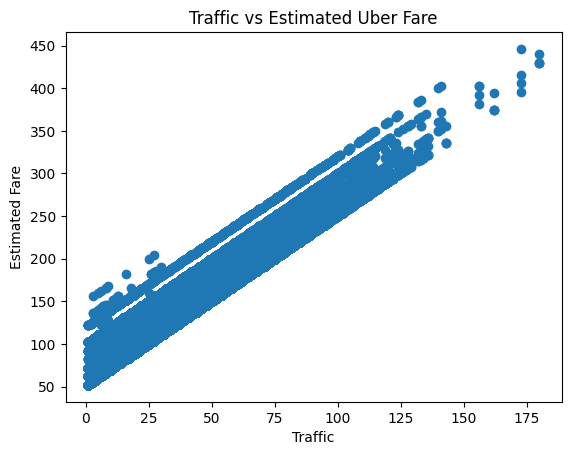

In [ ]:
merged['fare'] = (
    50 +
    merged['traffic'] * 2 +
    merged['rain'] * 10 +
    merged['is_event'] * 15 +
    merged['hour'].apply(lambda x: 20 if x in [8,9,18,19] else 0)
)

plt.scatter(merged['traffic'], merged['fare'])
plt.xlabel("Traffic")
plt.ylabel("Estimated Fare")
plt.title("Traffic vs Estimated Uber Fare")
plt.show()

In [ ]:
merged.corr(numeric_only=True)

,location,traffic,id,temperature,humidity,wind,rain,is_event,hour,fare
location,1.000000e+00,-0.623702,0.227205,0.000797,0.000907,0.000143,0.000486,-7.942943e-03,-1.730366e-15,-0.567503
traffic,-6.237023e-01,1.000000,0.220865,0.000515,-0.002291,0.002164,-0.000894,-1.853347e-02,2.186405e-01,0.911295
id,2.272046e-01,0.220865,1.000000,0.002564,-0.000039,0.003366,0.000810,-7.802258e-02,1.148414e-05,0.199455
temperature,7.965728e-04,0.000515,0.002564,1.000000,-0.002043,0.001118,-0.001286,-6.529521e-03,3.606961e-03,0.000917
humidity,9.072456e-04,-0.002291,-0.000039,-0.002043,1.000000,0.002772,0.004848,-6.294549e-04,1.373282e-03,0.000633
wind,1.425573e-04,0.002164,0.003366,0.001118,0.002772,1.000000,0.006986,-3.928874e-03,9.150816e-03,0.005770
rain,4.856145e-04,-0.000894,0.000810,-0.001286,0.004848,0.006986,1.000000,-2.547164e-03,5.823757e-03,0.378572
is_event,-7.942943e-03,-0.018533,-0.078023,-0.006530,-0.000629,-0.003929,-0.002547,1.000000e+00,3.582180e-16,0.005444
hour,-1.730366e-15,0.218640,0.000011,0.003607,0.001373,0.009151,0.005824,3.582180e-16,1.000000e+00,0.221606
fare,-5.675031e-01,0.911295,0.199455,0.000917,0.000633,0.005770,0.378572,5.443673e-03,2.216065e-01,1.000000


In [ ]:
merged = merged.drop_duplicates()

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

merged[['traffic', 'temperature', 'humidity', 'wind']] = scaler.fit_transform(
    merged[['traffic', 'temperature', 'humidity', 'wind']]
)

In [ ]:
merged['day_of_week']=merged['timestamp'].dt.dayofweek
merged['month']=merged['timestamp'].dt.month
merged['is_weekend']=merged['day_of_week'].apply(lambda x: 1 if x >=5 else 0)
# lag feature
merged['traffic_lag1']=merged['traffic'].shift(1)
merged['traffic_lag2']=merged['traffic'].shift(2)
merged=merged.ffill()


In [ ]:
merged.corr(numeric_only=True)['traffic'].sort_values(ascending=False)

,traffic
traffic,1.000000
fare,0.911295
traffic_lag1,0.721014
traffic_lag2,0.442027
id,0.220865
hour,0.218640
wind,0.002164
temperature,0.000515
rain,-0.000894
humidity,-0.002291


<Axes: >

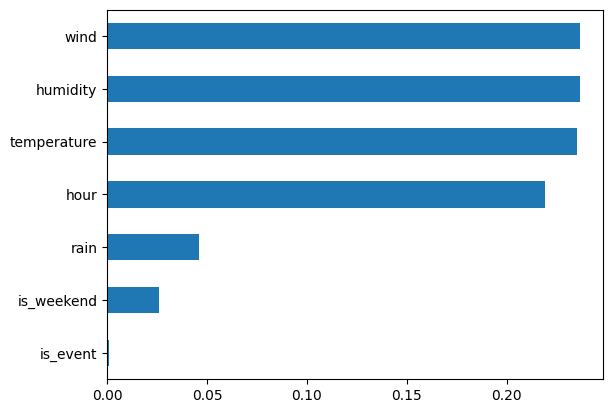

In [ ]:
from sklearn.ensemble import RandomForestRegressor

features = ['temperature', 'humidity', 'wind', 'rain', 'is_event', 'hour', 'is_weekend']
X = merged[features]
y = merged['traffic']

model = RandomForestRegressor()
model.fit(X, y)

importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

Peak hour: 20


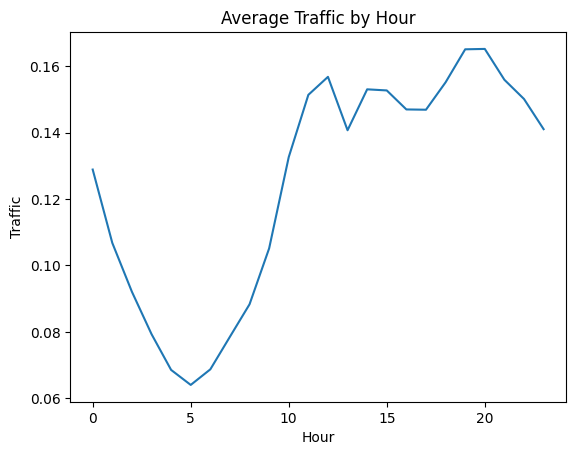

<Figure size 640x480 with 0 Axes>

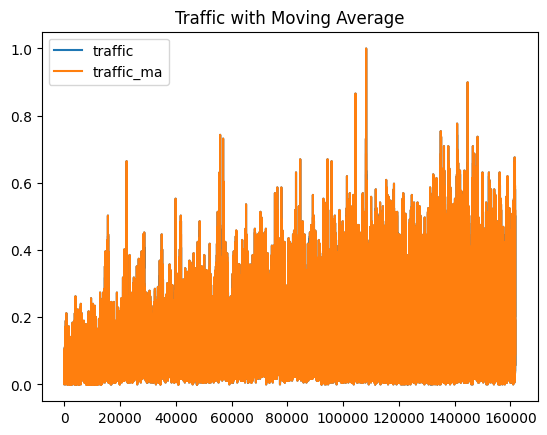

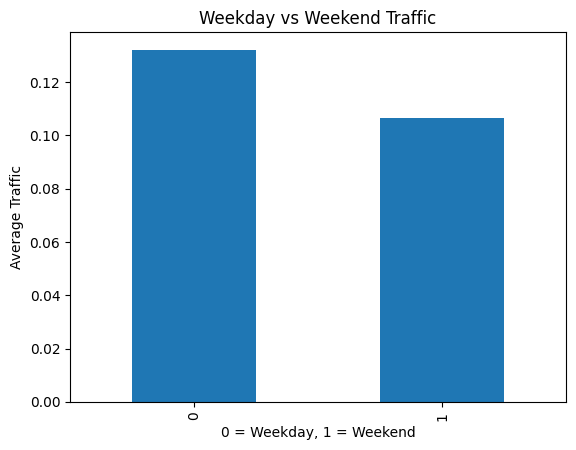

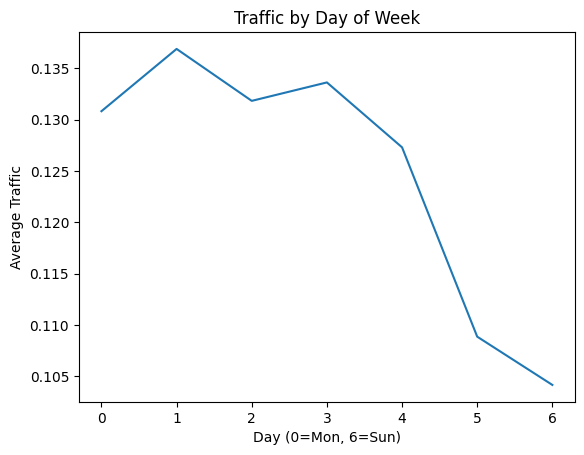

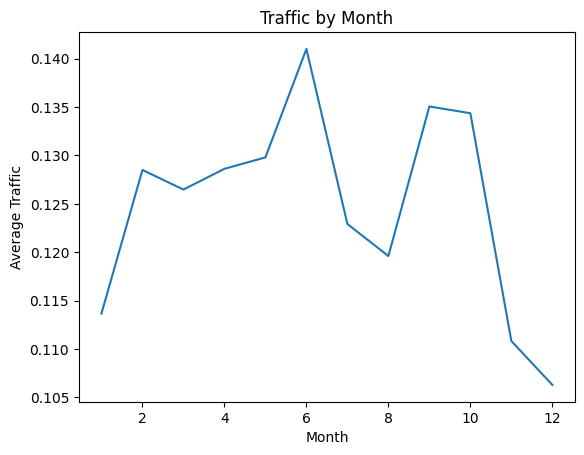

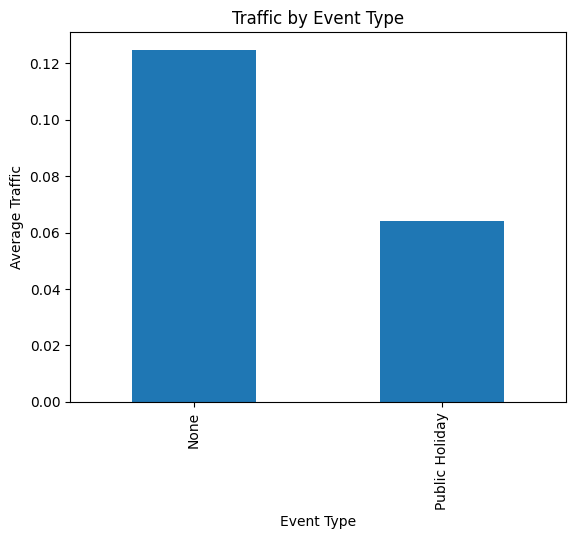

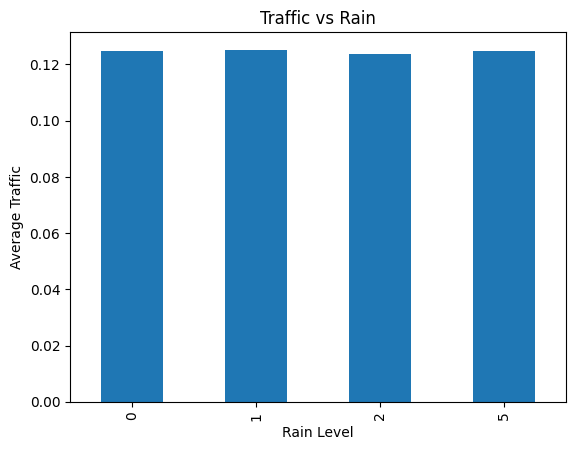

                  location   traffic        id  temperature  humidity  \
location      1.000000e+00 -0.623702  0.227205     0.000797  0.000907   
traffic      -6.237023e-01  1.000000  0.220865     0.000515 -0.002291   
id            2.272046e-01  0.220865  1.000000     0.002564 -0.000039   
temperature   7.965728e-04  0.000515  0.002564     1.000000 -0.002043   
humidity      9.072456e-04 -0.002291 -0.000039    -0.002043  1.000000   
wind          1.425573e-04  0.002164  0.003366     0.001118  0.002772   
rain          4.856145e-04 -0.000894  0.000810    -0.001286  0.004848   
is_event     -7.942943e-03 -0.018533 -0.078023    -0.006530 -0.000629   
hour         -1.730366e-15  0.218640  0.000011     0.003607  0.001373   
fare         -5.675031e-01  0.911295  0.199455     0.000917  0.000633   
day_of_week  -3.005651e-03 -0.083896 -0.016850    -0.006557 -0.000291   
month        -7.929330e-02 -0.021721 -0.362387     0.000334  0.000080   
is_weekend   -2.363833e-03 -0.096613 -0.015505    -

In [ ]:

import matplotlib.pyplot as plt
import pandas as pd


merged['hour'] = merged['timestamp'].dt.hour
merged['day_of_week'] = merged['timestamp'].dt.dayofweek
merged['month'] = merged['timestamp'].dt.month

hourly_avg = merged.groupby('hour')['traffic'].mean()
hourly_std = merged.groupby('hour')['traffic'].std()

#peak hour
peak_hour = hourly_avg.idxmax()
print("Peak hour:", peak_hour)

merged['traffic_ma'] = merged['traffic'].rolling(window=3).mean()

plt.figure()
hourly_avg.plot()
plt.title("Average Traffic by Hour")
plt.xlabel("Hour")
plt.ylabel("Traffic")
plt.show()


plt.figure()
merged[['traffic', 'traffic_ma']].plot()
plt.title("Traffic with Moving Average")
plt.show()

plt.figure()
merged.groupby('is_weekend')['traffic'].mean().plot(kind='bar')
plt.title("Weekday vs Weekend Traffic")
plt.xlabel("0 = Weekday, 1 = Weekend")
plt.ylabel("Average Traffic")
plt.show()


plt.figure()
merged.groupby('day_of_week')['traffic'].mean().plot()
plt.title("Traffic by Day of Week")
plt.xlabel("Day (0=Mon, 6=Sun)")
plt.ylabel("Average Traffic")
plt.show()


plt.figure()
merged.groupby('month')['traffic'].mean().plot()
plt.title("Traffic by Month")
plt.xlabel("Month")
plt.ylabel("Average Traffic")
plt.show()

# Event impact on traffic
plt.figure()
merged.groupby('event_type')['traffic'].mean().plot(kind='bar')
plt.title("Traffic by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Average Traffic")
plt.show()

# Weather impact (rain vs traffic)
plt.figure()
merged.groupby('rain')['traffic'].mean().plot(kind='bar')
plt.title("Traffic vs Rain")
plt.xlabel("Rain Level")
plt.ylabel("Average Traffic")
plt.show()

# Correlation analysis
corr_matrix = merged.corr(numeric_only=True)
print(corr_matrix)

print("\nCorrelation with traffic:\n")
print(corr_matrix['traffic'].sort_values(ascending=False))

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
from sklearn.model_selection import GridSearchCV

# Sort by time
merged = merged.sort_values('timestamp')

# Features and target
features = ['temperature', 'humidity', 'wind', 'rain', 'is_event', 'hour', 'is_weekend']
X = merged[features]
y = merged['traffic']


split_index = int(len(merged) * 0.8)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]


model = RandomForestRegressor()

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(model, param_grid, cv=3)
grid.fit(X_train, y_train)

best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)


print("Best Parameters:", grid.best_params_)

MAE: 0.10352236096517299
Best Parameters: {'max_depth': 5, 'n_estimators': 100}


MAE: 0.10349175140223195
RMSE: 0.15128033378857933
R2 Score: 0.023987390486832294


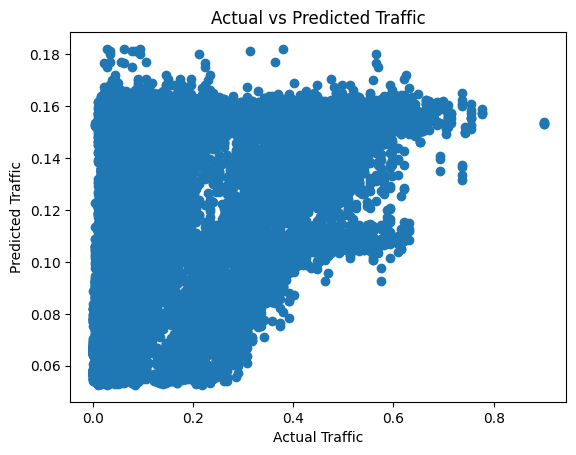

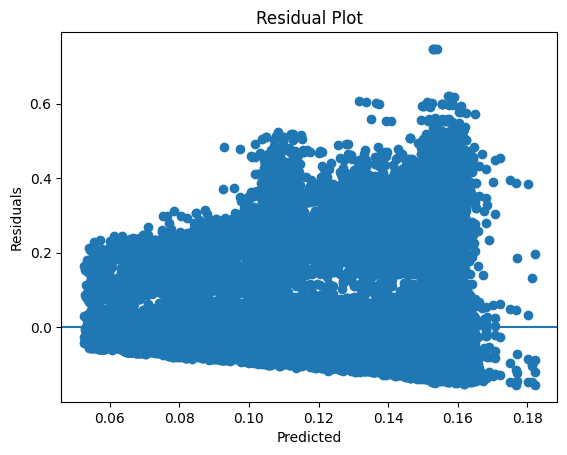

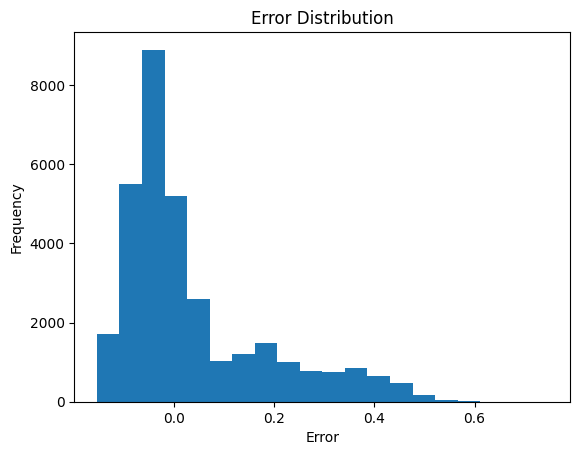

Cross-validation MAE scores: [0.06760345176726479, 0.08968257761803719, 0.10089553052983298]
Average CV MAE: 0.08606051997171166


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=50, max_depth=10)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)



mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Traffic")
plt.ylabel("Predicted Traffic")
plt.title("Actual vs Predicted Traffic")
plt.show()

#residual plot
residuals = y_test - y_pred

plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(0)
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#error dist
plt.figure()
plt.hist(residuals, bins=20)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


tscv = TimeSeriesSplit(n_splits=3)

cv_scores = []

for train_idx, test_idx in tscv.split(X):
    X_train_cv, X_test_cv = X.iloc[train_idx], X.iloc[test_idx]
    y_train_cv, y_test_cv = y.iloc[train_idx], y.iloc[test_idx]

    model_cv = RandomForestRegressor(n_estimators=50, max_depth=10)
    model_cv.fit(X_train_cv, y_train_cv)

    pred_cv = model_cv.predict(X_test_cv)
    score = mean_absolute_error(y_test_cv, pred_cv)
    cv_scores.append(score)

print("Cross-validation MAE scores:", cv_scores)
print("Average CV MAE:", np.mean(cv_scores))

In [ ]:
from sklearn.metrics import mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
import pandas as pd

#error analysis
errors = y_test - y_pred
error_df = pd.DataFrame({
    'actual': y_test,
    'predicted': y_pred,
    'error': errors
})


print(error_df.sort_values(by='error', key=abs, ascending=False).head())

merged['traffic_ma'] = merged['traffic'].rolling(3).mean()
merged = merged.ffill()

features = [
    'temperature', 'humidity', 'wind', 'rain',
    'is_event', 'hour', 'is_weekend',
    'traffic_lag1', 'traffic_lag2', 'traffic_ma'
]

X = merged[features]
y = merged['traffic']


split = int(len(merged)*0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

#improved model
model_refined = RandomForestRegressor(n_estimators=100, max_depth=10)
model_refined.fit(X_train, y_train)

y_pred_refined = model_refined.predict(X_test)

print("Refined MAE:", mean_absolute_error(y_test, y_pred_refined))

          actual  predicted     error
144682  0.899441   0.152964  0.746478
144681  0.899441   0.153008  0.746433
144680  0.899441   0.153570  0.745871
144683  0.899441   0.154075  0.745366
140910  0.776536   0.157074  0.619462
Refined MAE: 0.02916520137782433


In [ ]:
merged.to_csv("final_dataset.csv", index=False)